<a href="https://colab.research.google.com/github/chandrakalamohrirmohrir-bot/Assignment03-bitsom-ba-2511398-part4/blob/main/Part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd

df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nPass/fail count:")
print(df['passed'].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores(Passed students):")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage scores(Failed students):")
print(df[df['passed'] == 0][subject_cols].mean())

df['average'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average'].idxmax()]

print("\nTop student based on average:")
print(top_student['name'], "with average =", top_student['average'])

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset:
(15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:
            math    science    

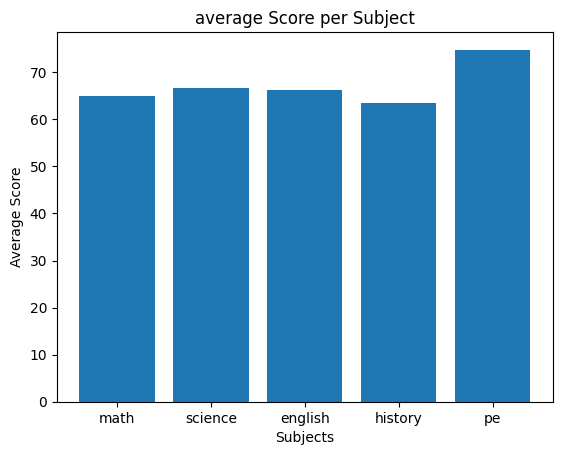

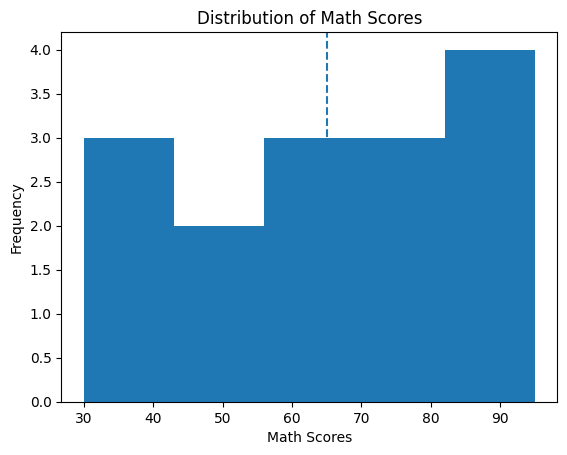

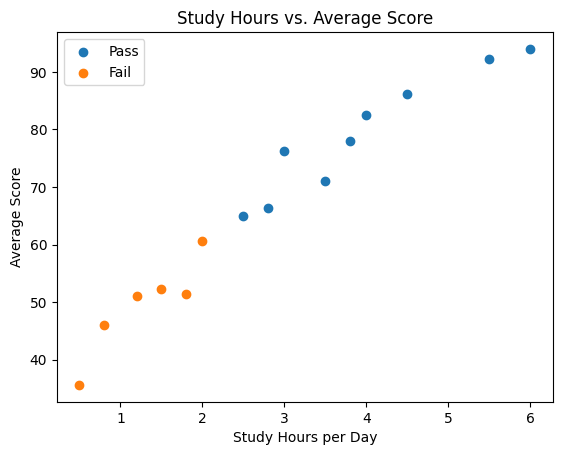

/tmp/ipykernel_1615/1532028753.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendence, fail_attendence], labels=['Pass', 'Fail'])


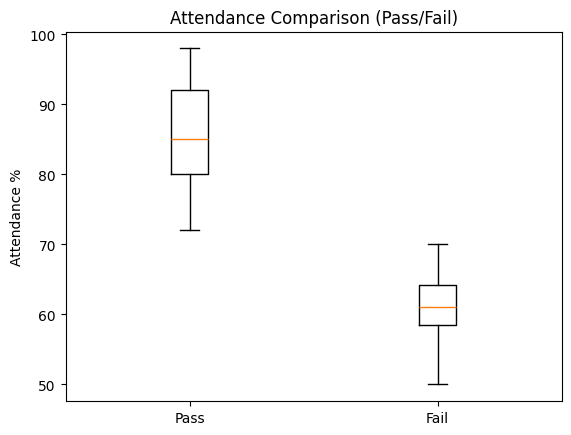

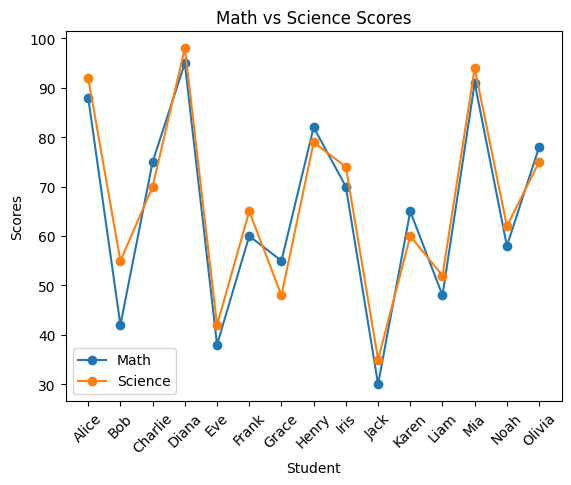

In [2]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#1. BAR CHART
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

#2.Histogram
plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")

plt.savefig("plot2_histogram.png")
plt.show()

#3. SCATTER PLOT
plt.figure()
passed = df[df['passed'] == 1]
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")

failed = df[df['passed'] == 0]
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

plt.title("Study Hours vs. Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

#4. BOX PLOT
pass_attendence = df[df['passed'] == 1]['attendance_pct']
fail_attendence = df[df['passed'] == 0]['attendance_pct']

plt.figure()
plt.boxplot([pass_attendence, fail_attendence], labels=['Pass', 'Fail'])
plt.title("Attendance Comparison (Pass/Fail)")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

#5 LINE PLOT
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='o', label='Science')

plt.title("Math vs Science Scores")
plt.xlabel("Student")
plt.ylabel("Scores")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

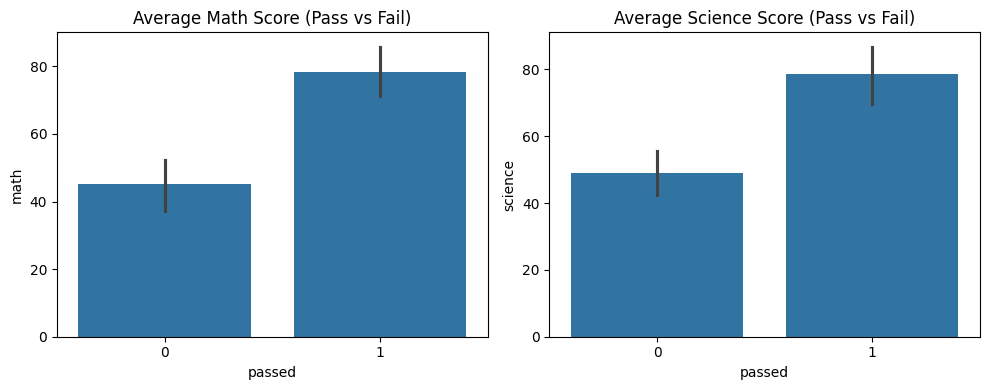

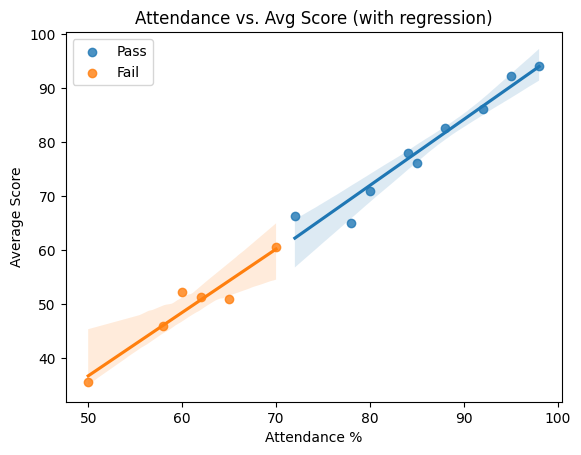

In [3]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#1. SEABORN BAR PLOTS(2 plots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#Math bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")

#science bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")

plt.tight_layout()
plt.savefig("plot1_seaborn_bar.png")
plt.show()

#2. SEABORN SCATTER + regression

plt.figure()

#pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

#Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.title("Attendance vs. Avg Score (with regression)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot2_seaborn_scatter.png")
plt.show()

# 3. COMMENT

# Seaborn makes visualization easier and more attractive compared to Matplotlib.
# It automatically handles grouping (like pass vs fail) and styling.
# Matplotlib requires more manual coding, whie Seaborn simplifies complex plots.

Training Accuracy: 1.0
Testing Accuracy: 1.0

Predictions:
Jack: Actual=0, Predicted=0 -> Correct
Liam: Actual=0, Predicted=0 -> Correct
Alice: Actual=1, Predicted=1 -> Correct

Feature Importance:
               feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


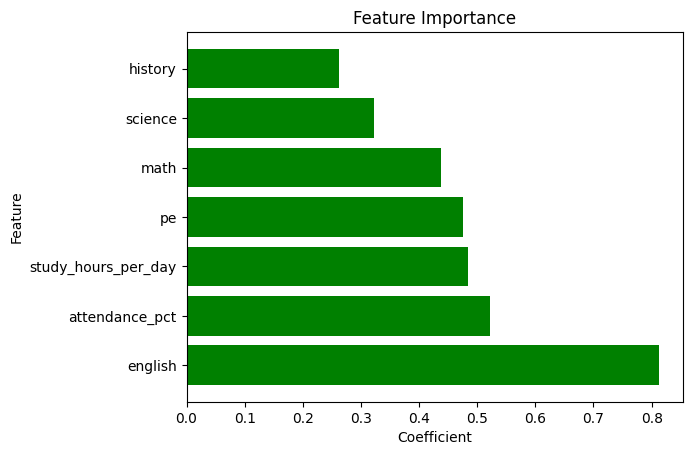


New Student Prediction:
Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

# step 1: Prepare Data

#Feature (X) and Target (y)
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#STEP 2: Train Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

#Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

#step 3: Evaluate Model

#predictions
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Testing Accuracy:", test_acc)

print("\nPredictions:")
for i in range(len(y_test)):
  name = df.loc[X_test.index[i], 'name']
  actual = y_test.iloc[i]
  pred = y_pred[i]
  result = "Correct" if actual == pred else "wrong"

  print(f"{name}: Actual={actual}, Predicted={pred} -> {result}")

#Step 4: Feature Importance

coefficients = model.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'Coefficient': coefficients
})

#sort by absolute value
importance_df['abs'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='abs', ascending=False)

print("\nFeature Importance:")
print(importance_df[['feature', 'Coefficient']])

#plot
plt.figure()
colors = ['green' if x > 0 else 'red' for x in importance_df['Coefficient']]

plt.barh(importance_df['feature'], importance_df['Coefficient'], color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

#Step 5: Predict New Student

new_student =[[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

print("\nNew Student Prediction:")
print("Pass" if prediction[0] == 1 else "Fail")
print("Probability:", probability)

In [5]:
from google.colab import files
files.download("students.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>